<a href="https://colab.research.google.com/github/Gilf4/lab3_ml/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Лабораторная работа 4, Смирнов Егор 23-ИИ.  
### Вариант 4/3.
Face Detectors - **MTCNN**  
Face recognition models - **OpenFace**

In [31]:
#функция со stackowerflow для захвата камеры в колабе
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

## Детекция лица на фото через MTCNN

In [32]:
pip install mtcnn opencv-python numpy

<IPython.core.display.Javascript object>

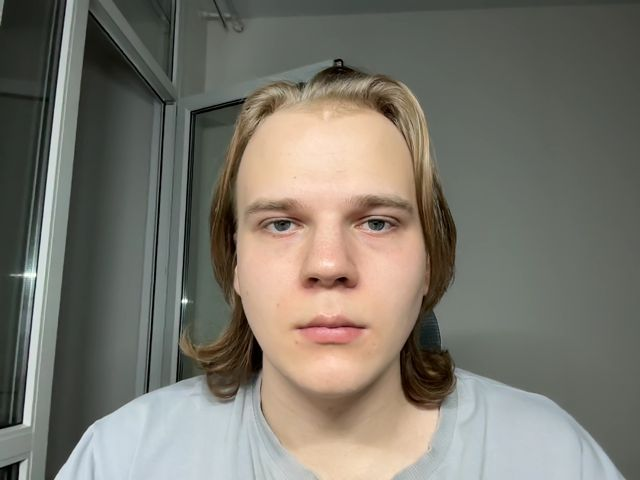

In [64]:
import cv2
from mtcnn import MTCNN
import matplotlib.pyplot as plt
from IPython.display import Image, Image as IPImage
import numpy as np

filename = take_photo(filename='main.jpg', quality=0.8)
display(IPImage(filename))

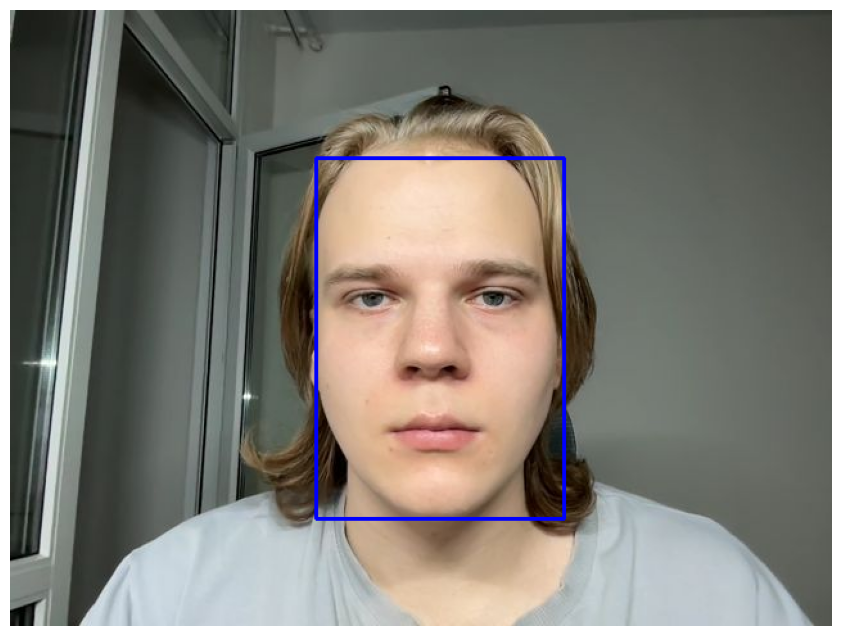

In [65]:
image = cv2.imread(filename)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

detector = MTCNN()
faces = detector.detect_faces(image_rgb)

image_with_bbox = image_rgb.copy()

if faces:
    for face in faces:
        x, y, w, h = face['box']

        cv2.rectangle(image_with_bbox, (x, y), (x + w, y + h), (0, 0, 255), 2)
else:
    print("Лица нет")

plt.figure(figsize=(12, 8))
plt.imshow(image_with_bbox)
plt.axis('off')
plt.show()

## Формирование вектора признаков лица через OpenFace

In [36]:
!pip install deepface

In [37]:
from deepface import DeepFace

In [66]:
embedding = DeepFace.represent(filename, model_name='OpenFace', detector_backend='mtcnn')

print(f"Вектор признаков: {embedding}")
print()

Вектор признаков: [{'embedding': [0.048862289637327194, 0.04299565777182579, -0.11212408542633057, 0.04885277897119522, 0.042101528495550156, 0.039184629917144775, -0.08580943942070007, -0.052520591765642166, -0.021911349147558212, 0.004540884867310524, 0.07078741490840912, 0.07590693235397339, 0.07962693274021149, -0.1387753188610077, -0.18329496681690216, 0.15579313039779663, -0.021321890875697136, 0.08540187776088715, -0.11782147735357285, 0.22959986329078674, 0.19941632449626923, -0.15886540710926056, 0.14991645514965057, 0.1344619244337082, -0.036383457481861115, 0.023344924673438072, 0.017200404778122902, -0.20217753946781158, 0.04240664467215538, 0.07803550362586975, -0.042421936988830566, 0.055110834538936615, 0.044649843126535416, 0.07905302941799164, -0.05051789805293083, -0.0005122772417962551, -0.05118078738451004, 0.19295231997966766, -0.038043662905693054, -0.08214659988880157, -0.14109031856060028, -0.071539506316185, -0.010791167616844177, 0.07160399854183197, -0.014846

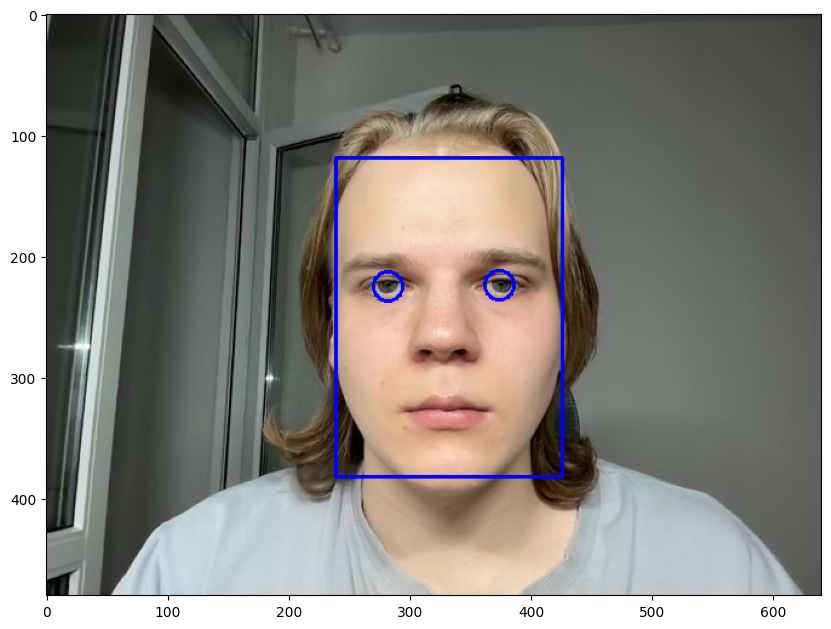

In [69]:
area = embedding[0]['facial_area']
x = area['x']
y = area['y']
w = area['w']
h = area['h']

img_show = image_rgb.copy()

cv2.rectangle(img_show, (x, y), (x + w, y + h), (0, 0, 255), 2)

cv2.circle(img_show, area['left_eye'],       12, (0, 0, 255), 2)
cv2.circle(img_show, area['right_eye'],      12, (0, 0, 255), 2)

plt.figure(figsize=(10, 10))
plt.imshow(img_show)
plt.show()

## Захватываем веб-камеру, выполняем верификацию в реальном времени

In [70]:
import numpy as np

def process_frame(image_path, embedding):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    faces = detector.detect_faces(image_rgb)

    if faces:
        x, y, width, height = faces[0]['box']

        current_embedding = DeepFace.represent(image_rgb, model_name="OpenFace", detector_backend="mtcnn", enforce_detection=False)

        current_embedding = np.array(current_embedding[0]['embedding'])
        embedding = np.array(embedding[0]['embedding'])
        distance = np.linalg.norm(embedding - current_embedding)
        print(f"Евклидово расстояние: {distance:.4f}")

        return distance
    else:
        print("Лицо не найдено в кадре")
        return None

In [72]:
def start(embedding):
  while True:
      filename = take_photo('frame.jpg')
      display(Image(filename))
      process_frame(filename, embedding)

<IPython.core.display.Javascript object>

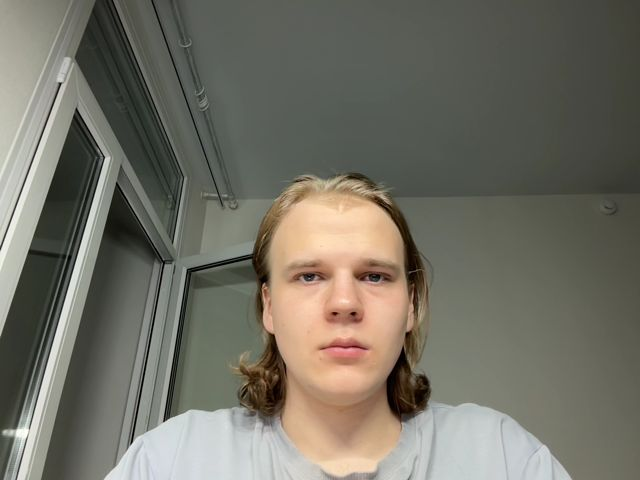

Евклидово расстояние: 0.4565


<IPython.core.display.Javascript object>

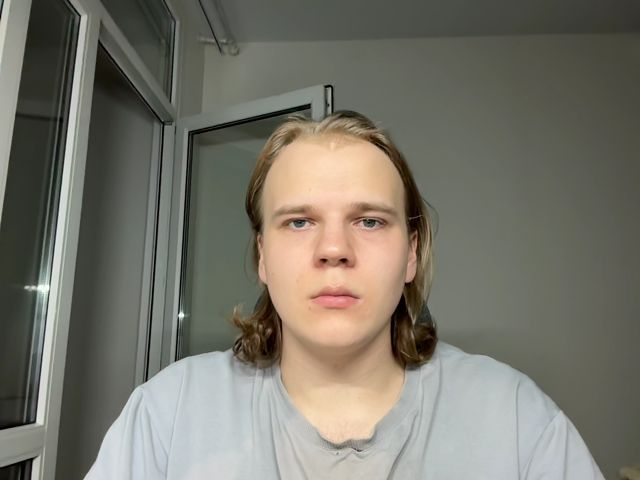

Евклидово расстояние: 0.5293


<IPython.core.display.Javascript object>

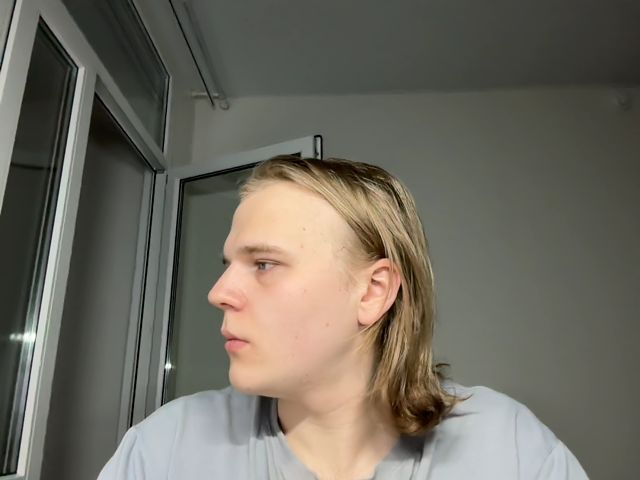

Евклидово расстояние: 0.8443


<IPython.core.display.Javascript object>

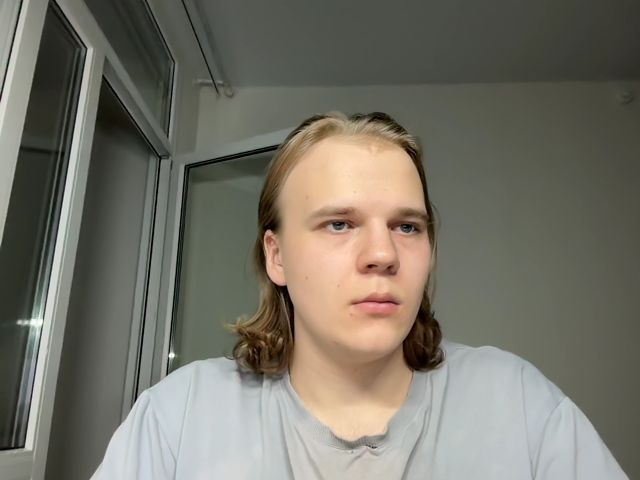

Евклидово расстояние: 0.5764


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [73]:
start(embedding)

## Видим, что модель хорошо верефицирует лицо, но чувствительна к поворотам головы

In [74]:
other_result = DeepFace.represent("other.jpeg", model_name="OpenFace", detector_backend="mtcnn", align=True)

other_embedding = np.array(other_result[0]["embedding"])
np_embedding = np.array(embedding[0]['embedding'])

In [75]:
distance = np.linalg.norm(np_embedding - other_embedding)

print(f"Евклидово расстояние для другого лица: {distance:.4f}")

Евклидово расстояние для другого лица: 1.0781


# Для лица другого человека Евклидово расстояние > 1

<IPython.core.display.Javascript object>

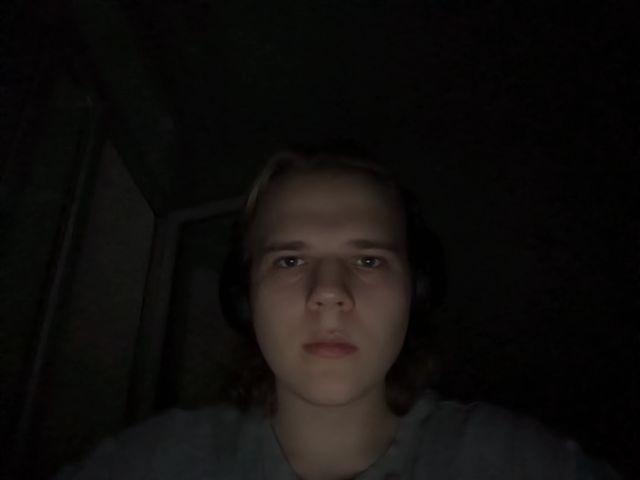

Евклидово расстояние: 0.6249


<IPython.core.display.Javascript object>

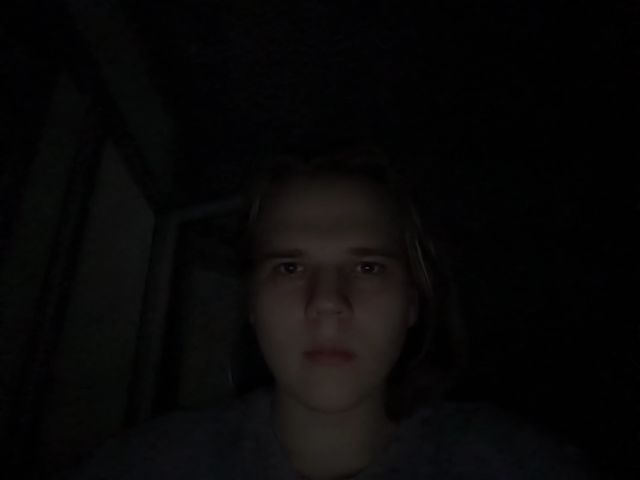

Евклидово расстояние: 0.5457


<IPython.core.display.Javascript object>

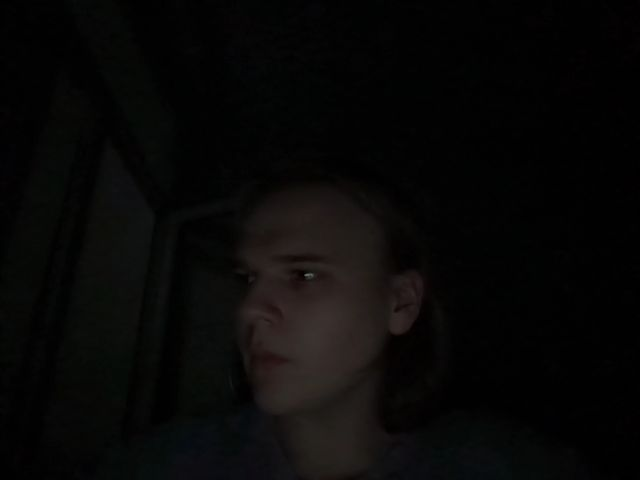

Евклидово расстояние: 0.8414


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [77]:
start(embedding)

## В темноте модель чуть хуже верифицирует лицо